In [65]:
import importlib
import cisei_lib.geo_datasets.dem_utils as du
import cisei_lib.geo_datasets.gob_heights_utils as gh
importlib.reload(du)
importlib.reload(gh)
# %who 
# %whos  # List with details
# %reset -f  # Clear all variables (force)

<module 'cisei_lib.geo_datasets.gob_heights_utils' from '/home/einstein-bohr/Documents/PYTHON/cisei_lib/geo_datasets/gob_heights_utils.py'>

In [ ]:
# CHECK AND FILTER DOWNLOAD URLS

In [4]:
# Example for your tile ASTGTMV003_S23W052_dem.tif
tokens = gh.get_tokens_for_bbox(-23.0001, -21.9998, -52.0001, -50.9998, 4)
print(f"Required Google Tiles: {tokens}")
file = 'open_building_url/curitiba_metro_urls.txt'
index = gh.check_open_buildings_urls(file)
print(len(index))
print(index[0])
curitiba_box = {
    "min_lat": -25.60, 
    "max_lat": -25.30,
    "min_lon": -49.45,
    "max_lon": -49.15
}
# Example usage
original = 'open_building_url/parana_urls.txt'
gh.filter_urls_by_bbox(original, 'open_building_url/teste_urls.txt', curitiba_box)


Required Google Tiles: ['949', '94f']
14
{'filename': 'tile_jeqWjwK4Zzg.tif', 'token': '94d9c', 'level': 7, 'min_lat': -26.475750073412787, 'max_lat': -25.633865670295947, 'min_lon': -48.08035294648419, 'max_lon': -47.44903973835813}
Filtering complete. Saved 129 URLs to open_building_url/teste_urls.txt.


In [ ]:
# DOWNLOAD GOOGLE TILES

In [ ]:
# Download Google Tiles
urls = 'open_building_url/parana_squared_urls.txt'
existing = ['G-Heights', 'openbuilding-curitiba']
# gh.download_open_building_tiffs(urls, 'G-Heights', existing)
# cleanup_tiles('curitiba_test', 'open_building_url/curitiba_filtered_urls.txt', 'G-Heights')

In [ ]:
# CREATE INDEX OF DOWLOADED TILES

In [18]:
## Create a TXT index of dowloaded tiles
# du.create_geotiff_index('openbuilding-curitiba')
#du.create_global_tile_index('openbuilding-curitiba', 'curitiba_tiles_geo.json')
# create_global_tile_index('copernicus_dsm_parana', 'copernicus_tiles_geo.json')
# create_global_tile_index('fabdem_dtm_parana', 'fabdem_tiles_geo.json')
#create_global_tile_index('ersi-cover', 'index-geo.json')

Index complete: 129 tiles processed. File saved to curitiba_tiles_geo.json


In [ ]:
# LOCATE TILE AND PLOT SINGLE BAND

filename Copernicus_DSM_COG_10_S26_00_W050_00_DEM.tif
crs_native EPSG:4326
px_dimensions 3600x3600
band_count 1
bands {'band_1': 'gray'}
True
Highest Obstacle: 88.56m
Coordinates: -25.43528062189526, -49.275898666126444


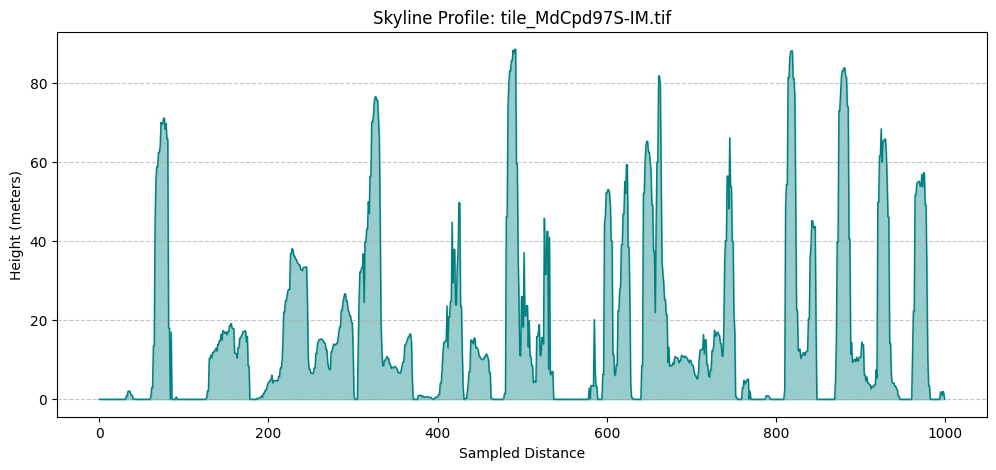

In [68]:
dir = 'openbuilding-curitiba'
dir = 'copernicus-dsm-parana'
file_path = f'{dir}/index-geo.json'
# file_path = 'copernicus_tiles_geo.json'
test_lat = -25.431874
test_lon = -49.275916
result = du.find_tile_by_coord(file_path, test_lat, test_lon)
for k,v in result.items(): print(k,v)
# --- Usage ---
#du.process_band(f"{dir}/{result['filename']}", 1)  
#du.process_band(f"{dir}/{result['filename']}", 2, 20)  

# Link coordinates
dir = 'openbuilding-curitiba'
file_path = f'{dir}/index-geo.json'
start = (-25.4297, -49.2719)
end = (-25.4411, -49.2800)

result_start = du.find_tile_by_coord(file_path, *start)
result_end = du.find_tile_by_coord(file_path, *end)

print(result_start['filename'] == result_end['filename'])

gh.plot_height_profile(f"{dir}/{result_start['filename']}", start, end, step = 5) 
